# P3 — Weighted Resample to 5,000 Household Agents

Draw **5,000 households** from the matched population with probability ∝ the NIDS survey weight
(`w5_wgt`), with replacement. After resampling, **each agent is equally representative** — downstream
statistics are computed **unweighted**, and should reproduce the *weighted* source distribution.
This fixed-size population is the agent set for the ABM. See [`../OVERVIEW.md`](../OVERVIEW.md).

## 1. Setup & load matched population

In [1]:
import pandas as pd, numpy as np, json
from pathlib import Path
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110

def find_root(start=Path.cwd()):
    for d in [start, *start.parents]:
        if (d / "data/processed/synthetic_population_matched.parquet").exists():
            return d
    raise FileNotFoundError("run P2 first")
ROOT = find_root(); PROC = ROOT / "data/processed"
pop = pd.read_parquet(PROC / "synthetic_population_matched.parquet")
QORDER = ["Q1", "Q2", "Q3", "Q4", "Q5"]
pop["income_quintile"] = pd.Categorical(pop["income_quintile"], QORDER, ordered=True)
flags = ["banked", "credit_access_formal", "informal_finance", "savings_product"]
for f in flags: pop[f] = pop[f].astype(int)
N, SEED = 5000, 20240601
print("source:", len(pop), "households | weighted pop:", f"{pop.w5_wgt.sum():,.0f}")

source: 10841 households | weighted pop: 18,670,046


## 2. Resample

In [2]:
rng = np.random.RandomState(SEED)
p = (pop.w5_wgt / pop.w5_wgt.sum()).values
idx = rng.choice(len(pop), size=N, replace=True, p=p)
agents = pop.iloc[idx].reset_index(drop=True).copy()
agents.insert(0, "agent_id", np.arange(N))
agents = agents.rename(columns={"w5_hhid": "source_w5_hhid", "w5_wgt": "source_weight"})
# post-resample each agent counts equally; source_weight kept only for traceability
print("agents:", len(agents), "| unique source households drawn:", agents.source_w5_hhid.nunique())
agents.head(3)

agents: 5000 | unique source households drawn: 3250


,agent_id,source_w5_hhid,source_weight,w5_hhsizer,province,w5_hhincome,income_pc,income_quintile,income_source,expenditure_total,...,savings_product,K7,G10,G11,G12,G13,G14,repay_uncapped,monthly_trad_repayment,dsti
0,0,505607,4976.22950,3.0,Gauteng,4391.0000,1463.666667,Q2,WAGE,3715.0000,...,0,,No,No,No,No,No,480.343683,480.343683,0.109393
1,1,506281,4354.11960,1.0,Gauteng,12000.0000,12000.000000,Q5,WAGE,10156.0000,...,1,"R1,000 - R1,999",Yes,No,No,No,No,131.347591,131.347591,0.010946
2,2,502619,274.66034,5.0,Northern Cape,5298.5312,1059.706240,Q2,GRANT,2703.5315,...,0,,No,No,No,No,No,10.674304,10.674304,0.002015


## 3. Resample fidelity — unweighted 5,000 vs weighted source

The resampled agents (each equal) should reproduce the weighted source distribution.

In [3]:
def wgini(x, w):
    x = np.asarray(x, float); w = np.asarray(w, float); o = np.argsort(x); x, w = x[o], w[o]
    cw = np.cumsum(w); cxw = np.cumsum(x * w)
    return 1 - np.sum((cxw[1:] + cxw[:-1]) * np.diff(cw)) / (cxw[-1] * cw[-1])

cmp = pd.DataFrame({
    "source_weighted": {
        **{f"share_{q}": (pop.loc[pop.income_quintile == q, "w5_wgt"].sum() / pop.w5_wgt.sum()) * 100 for q in QORDER},
        **{f: np.average(pop[f], weights=pop.w5_wgt) * 100 for f in flags},
        "gini_pc": wgini(pop.income_pc, pop.w5_wgt),
        "mean_hh_income": np.average(pop.w5_hhincome, weights=pop.w5_wgt),
        "mean_hh_size": np.average(pop.w5_hhsizer, weights=pop.w5_wgt)},
    "agents_unweighted": {
        **{f"share_{q}": (agents.income_quintile == q).mean() * 100 for q in QORDER},
        **{f: agents[f].mean() * 100 for f in flags},
        "gini_pc": wgini(agents.income_pc, np.ones(len(agents))),
        "mean_hh_income": agents.w5_hhincome.mean(),
        "mean_hh_size": agents.w5_hhsizer.mean()}})
cmp["diff"] = cmp.agents_unweighted - cmp.source_weighted
cmp.round(2)

,source_weighted,agents_unweighted,diff
share_Q1,20.44,21.50,1.06
share_Q2,19.57,18.94,-0.63
share_Q3,20.11,20.10,-0.01
share_Q4,19.88,19.68,-0.20
share_Q5,19.99,19.78,-0.21
banked,82.77,83.06,0.29
credit_access_formal,28.65,28.70,0.05
informal_finance,9.21,9.34,0.13
savings_product,51.76,52.06,0.30
gini_pc,0.65,0.67,0.02


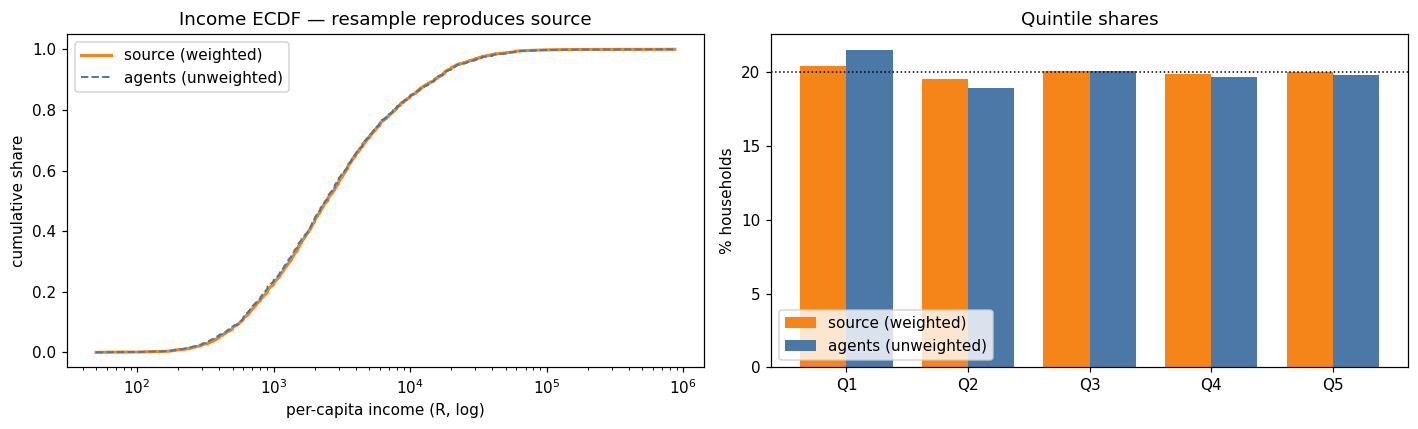

In [4]:
# income ECDF: weighted source vs unweighted agents
xs = np.sort(pop.income_pc.values); ws = pop.w5_wgt.values[np.argsort(pop.income_pc.values)]
Fsrc = np.cumsum(ws) / ws.sum()
xa = np.sort(agents.income_pc.values); Fag = np.arange(1, len(xa) + 1) / len(xa)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(xs, Fsrc, label="source (weighted)", color="#F58518", lw=2)
axes[0].plot(xa, Fag, label="agents (unweighted)", color="#4C78A8", lw=1.3, ls="--")
axes[0].set(xscale="log", xlabel="per-capita income (R, log)", ylabel="cumulative share",
            title="Income ECDF — resample reproduces source"); axes[0].legend()
sh_src = [cmp.loc[f"share_{q}", "source_weighted"] for q in QORDER]
sh_ag = [cmp.loc[f"share_{q}", "agents_unweighted"] for q in QORDER]
x = np.arange(5); w = 0.38
axes[1].bar(x - w/2, sh_src, w, label="source (weighted)", color="#F58518")
axes[1].bar(x + w/2, sh_ag, w, label="agents (unweighted)", color="#4C78A8")
axes[1].set_xticks(x); axes[1].set_xticklabels(QORDER); axes[1].axhline(20, color="k", ls=":", lw=1)
axes[1].set(ylabel="% households", title="Quintile shares"); axes[1].legend()
plt.tight_layout(); plt.show()

## 4. Population-size stability check (1k / 5k / 10k)

In [5]:
rows = []
for n in [1000, 5000, 10000]:
    a = pop.iloc[np.random.RandomState(SEED).choice(len(pop), n, replace=True, p=p)]
    rows.append({"N": n, "gini_pc": round(wgini(a.income_pc, np.ones(len(a))), 3),
                 "mean_pc_income": round(a.income_pc.mean(), 0),
                 "banked_%": round(a.banked.mean() * 100, 1),
                 "credit_%": round(a.credit_access_formal.mean() * 100, 1),
                 "max_quintile_dev_pp": round(max(abs((a.income_quintile == q).mean() * 100 - 20) for q in QORDER), 2)})
pd.DataFrame(rows).set_index("N")

,gini_pc,mean_pc_income,banked_%,credit_%,max_quintile_dev_pp
N,,,,,
1000,0.648,5589.0,84.6,28.6,2.00
5000,0.671,6440.0,83.1,28.7,1.50
10000,0.663,6370.0,82.6,28.0,0.91


## 5. Persist

In [6]:
out = PROC / "synthetic_population_5000.parquet"
agents.to_parquet(out, index=False)
agents.head(50).to_csv(PROC / "synthetic_population_5000_preview.csv", index=False)
summ = {"n_agents": N, "seed": SEED, "unique_source_households": int(agents.source_w5_hhid.nunique()),
        "gini_pc_agents": round(float(wgini(agents.income_pc, np.ones(len(agents)))), 3),
        "max_quintile_share_dev_pp": round(float(max(abs((agents.income_quintile == q).mean()*100 - 20) for q in QORDER)), 2)}
(PROC / "p3_resample_summary.json").write_text(json.dumps(summ, indent=2))
print(json.dumps(summ, indent=2)); print("wrote:", out.name)

{
  "n_agents": 5000,
  "seed": 20240601,
  "unique_source_households": 3250,
  "gini_pc_agents": 0.671,
  "max_quintile_share_dev_pp": 1.5
}
wrote: synthetic_population_5000.parquet


Next — **P5**: instantiate Mesa agents from `synthetic_population_5000.parquet`.